In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

base = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'

condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']

condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': '#e7533a',
    '23129': '#e7533a',
    '33300': '#e7533a',
}

# Real dishes and their pseudo dishes, which hold larvae that never actually shared a plate.
real = pd.concat(
    [pd.read_csv(f'{base}/{c}/closest_contacts_1mm.csv').assign(condition=c, source='real') for c in condition_order],
    ignore_index=True,
)


df = pd.concat([real], ignore_index=True)


print(df.groupby(['condition', 'source'])['file'].nunique().unstack().loc[condition_order])


source     real
condition      
wiii8        10
anosmic      10
9047         10
23129        10
33300        10


In [9]:
# Contact coordinates are in mm but in each dish's own frame, so re-centre every file on its arena.
DISH_DIAMETER_MM = 90
DEFAULT_DIAMETER_PX = 1032
DEFAULT_CENTRE_PX = np.array([700.0, 700.0])
CONVERSION_THRESHOLD = 0.09

import os
import glob
from shapely import wkt

def recording_key(name):
    return '_'.join(os.path.basename(name).split('_')[:2])

centres = {}
missing = []

for condition in condition_order:
    perimeters = {recording_key(p): p for p in glob.glob(f'{base}/{condition}/*_perimeter.wkt')}

    for track_file in df.loc[df['condition'] == condition, 'file'].dropna().unique():
        perimeter_path = perimeters.get(recording_key(track_file))

        if perimeter_path is None:
            centres[(condition, track_file)] = DEFAULT_CENTRE_PX * (DISH_DIAMETER_MM / DEFAULT_DIAMETER_PX)
            missing.append(track_file)
            continue

        with open(perimeter_path) as f:
            polygon = wkt.loads(f.read())

        minx, miny, maxx, maxy = polygon.bounds
        conversion_factor = DISH_DIAMETER_MM / (maxx - minx)

        # same badly-detected-perimeter guard as the analysis class
        if conversion_factor > CONVERSION_THRESHOLD:
            conversion_factor = DISH_DIAMETER_MM / DEFAULT_DIAMETER_PX

        centres[(condition, track_file)] = np.array([polygon.centroid.x, polygon.centroid.y]) * conversion_factor

contacts = df.dropna(subset=['x_contact', 'y_contact']).copy()
centre_coords = np.array([centres[(c, f)] for c, f in zip(contacts['condition'], contacts['file'])])
contacts['x_centred'] = contacts['x_contact'] - centre_coords[:, 0]
contacts['y_centred'] = contacts['y_contact'] - centre_coords[:, 1]

print(f'{len(contacts)} contacts; {len(set(missing))} files had no perimeter file and used the default centre')
print(contacts.groupby('condition')['file'].nunique().loc[condition_order])


15153 contacts; 0 files had no perimeter file and used the default centre
condition
wiii8      10
anosmic    10
9047       10
23129      10
33300      10
Name: file, dtype: int64


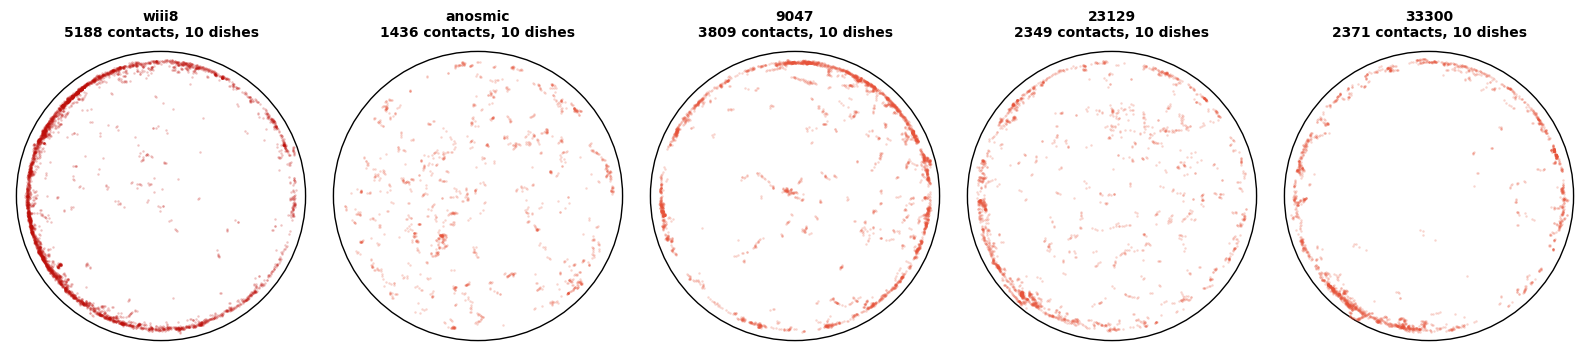

In [10]:
# Where in the dish contacts happen, one panel per condition.
DISH_RADIUS_MM = 45
POINT_SIZE = 3
POINT_ALPHA = 0.25

fig, axes = plt.subplots(1, 5, figsize=(16, 3.8), sharex=True, sharey=True)

for ax, condition in zip(axes, condition_order):

    plot_data = contacts[contacts['condition'] == condition]

    ax.add_patch(plt.Circle((0, 0), DISH_RADIUS_MM, fill=False, edgecolor='black', linewidth=1))
    ax.scatter(
        plot_data['x_centred'], plot_data['y_centred'],
        s=POINT_SIZE, alpha=POINT_ALPHA, linewidths=0,
        color=condition_colors[condition],
    )

    ax.set_title(
        f"{condition}\n{len(plot_data)} contacts, {plot_data['file'].nunique()} dishes",
        fontsize=10, fontweight='bold',
    )
    ax.set_xlim(-DISH_RADIUS_MM - 2, DISH_RADIUS_MM + 2)
    ax.set_ylim(-DISH_RADIUS_MM - 2, DISH_RADIUS_MM + 2)
    ax.set_aspect('equal')
    ax.axis('off')

axes[0].invert_yaxis()  # match the video's image coordinates

plt.tight_layout()
plt.show()
